# Regla Compuesta de Simpson

**Nombre:** Gutierrez Leon Giannine Valeria
**Fecha:** 05/10/2026

### Objetivo
Implementar la Regla Compuesta de Simpson siguiendo el Algoritmo 4.1 del libro de Burden y utilizarla para aproximar una integral definida con un error menor que $10^{-4}$.

#Como problema de prueba se utilizará la integral

$$I=\int_0^2 e^{2x}\sin(3x)\,dx$$

La regla compuesta de Simpson divide el intervalo $[a,b]$ en $n$ subintervalos de igual longitud.
Para utilizar este método, $n$ debe ser un número entero **par**.
El tamaño de cada subintervalo se calcula mediante

$$h=\frac{b-a}{n}$$

Los puntos de la partición son

$$x_i=a+ih,\qquad i=0,1,\ldots,n$$

La frmula de la regla compuesta de Simpson es

$$\int_a^b f(x)\,dx\approx\frac{h}{3}\left[f(x_0)+f(x_n)+4\sum_{\substack{i=1\\i\text{ impar}}}^{n-1}f(x_i)+2\sum_{\substack{i=2\\i\text{ par}}}^{n-2}f(x_i)\right]$$

Los puntos interiores con índice impar se multiplican por $4$,mientras que los puntos interiores con índice par se multiplica por $2$.

La cota del error para la Regla Compuesta de Simpson está dada por
$$|E_S|\leq\frac{b-a}{180}h^4\max_{a\leq x\leq b}|f^{(4)}(x)|$$

Esto permite determinar un valor adecuado de $n$ para alcanzar una tolerancia 
En nuestro problema la tolerancia solicitada es

$$|E_S|<10^{-4}$$

Se desea aproximar la integral
$$I=\int_0^2 e^{2x}\sin(3x)\,dx$$

Por lo tanto, los datos del problema son
$$a=0,\qquad b=2,$$ y $$f(x)=e^{2x}\sin(3x)$$

La función se implementa mediante una de Python llamada `f`.


In [22]:
import math #para las funciones exponencial y el seno
import numpy as np #para generar los puntos necesarios para las graficas
import matplotlib.pyplot as plt #para representar graficamente la funcion y el comportamiento del error

def f(x):
    return math.exp(2*x)*math.sin(3*x)


La instrucción `return` devuelve el valor de la función para el
valor de entrada `x`.

Para determinar el número de subintervalos utilizamos la cota del error de Simpson.

La cuarta derivada de $$f(x)=e^{2x}\sin(3x)$$ es $$f^{(4)}(x)=-e^{2x}\left(119\sin(3x)+120\cos(3x)\right)$$

En el intervalo $[0,2]$ se tiene aproximadamente $$\max_{0\leq x\leq2}|f^{(4)}(x)|\approx4475.4098$$
La condición requerida es $$\frac{b-a}{180}h^4\max|f^{(4)}(x)|<10^{-4}$$

Como $$h=\frac{b-a}{n}=\frac{2}{n},$$ se obtiene $$\frac{2}{180}(4475.4098)\left(\frac{2}{n}\right)^4<10^{-4}$$
Al resolver esta desigualdad se obtiene $$n>53.11$$

Como la Regla Compuesta de Simpson requiere que $n$ sea par,seleccionamos $$\boxed{n=54}$$
Por lo tanto,$$h=\frac{2}{54}$$ y $$ \boxed{h=0.0370370370}$$


In [23]:
# Extremos del intervalo
a = 0.0
b = 2.0

# Número de subintervalos
n = 54

# Tolerancia solicitada
tolerancia = 1e-4

# Tamaño del paso
h = (b - a) / n
print("Datos del problema")
print("------------------")
print(f"a = {a}")
print(f"b = {b}")
print(f"n = {n}")
print(f"h = {h:.10f}")
print(f"Tolerancia = {tolerancia}")

Datos del problema
------------------
a = 0.0
b = 2.0
n = 54
h = 0.0370370370
Tolerancia = 0.0001


### Implementacion del Algoritmo 4.1 de Burden

La implementacion siguiente sigue la estructura del Algoritmo 4.1.

Se utilizan tres acumuladores:

- `XI0`: contiene los valores de los extremos.
- `XI1`: acumula los valores correspondientes a índices impares.
- `XI2`: acumula los valores correspondientes a índices pares.

Finalmente se utiliza la expresión

$$XI=\frac{h}{3}\left(XI0+2XI2+4XI1\right)$$

In [24]:
def simpson_compuesta(f, a, b, n):
    """Aproxima la integral de f(x) en [a,b]"""
    if n<=0 or n%2!=0:  #comprueba que el número de subintervalos sea positivo y par.
        raise ValueError("n debe ser un entero positivo y par.")

    #Paso 1:calcular h
    h=(b-a)/n
    
    #Paso 2:inicializar las sumas
    XI0 = f(a) + f(b)
    XI1 = 0.0
    XI2 = 0.0
    
    #Pasos 3, 4 y 5:
    #recorrer los puntos interiores
    for i in range(1, n):
        #Paso 4:calcular el punto x_i
        x=a+i*h
        #Paso 5:separar índices pares e impares
        if i%2==0:
            XI2=XI2+f(x)
        else:
            XI1=XI1+f(x)

    #Paso 6:calcular la aproximación
    XI=h*(XI0+2*XI2+4*XI1)/3
    
    # Paso 7: regresar el resultado
    return XI

aproximacion = simpson_compuesta(f, a, b, n)

print("Resultado de Simpson")
print(f"Aproximación = {aproximacion:.12f}")

Resultado de Simpson
Aproximación = -14.213964900135


Para comprobar la precisión del método podemos comparar el resultado
numérico con el valor exacto de la integral.

Una antiderivada de $$e^{2x}\sin(3x)$$ es $$\frac{e^{2x}}{13}\left(2\sin(3x)-3\cos(3x)\right)$$

Por lo tanto,$$I=\left[\frac{e^{2x}}{13}\left(2\sin(3x)-3\cos(3x)\right)\right]_0^2$$

In [25]:
# Valor exacto de la integral
valor_exacto=(math.exp(4)*(2*math.sin(6)-3*math.cos(6))/13+3/13)

# Error absoluto
error_absoluto=abs(valor_exacto-aproximacion)

print("Comparación")
print(f"Valor exacto={valor_exacto:.12f}")
print(f"Aproximación={aproximacion:.12f}")
print(f"Error absoluto={error_absoluto:.12e}")
print(f"Tolerancia={tolerancia:.1e}")


Comparación
Valor exacto=-14.213977129863
Aproximación=-14.213964900135
Error absoluto=1.222972797876e-05
Tolerancia=1.0e-04


La Regla Compuesta de Simpson con $n=54$ produce la aproximación

$$\boxed{I\approx -14.2139649001}$$
El error absoluto obtenido es$$\boxed{|E|\approx1.223\times10^{-5}}$$

Como $$1.223\times10^{-5}<10^{-4},$$ se concluye que la aproximación satisface la tolerancia solicitada.

A continuación se muestra la función $$f(x)=e^{2x}\sin(3x)$$ en el intervalo $[0,2]$, junto con los puntos utilizados por la Regla Compuesta de Simpson.


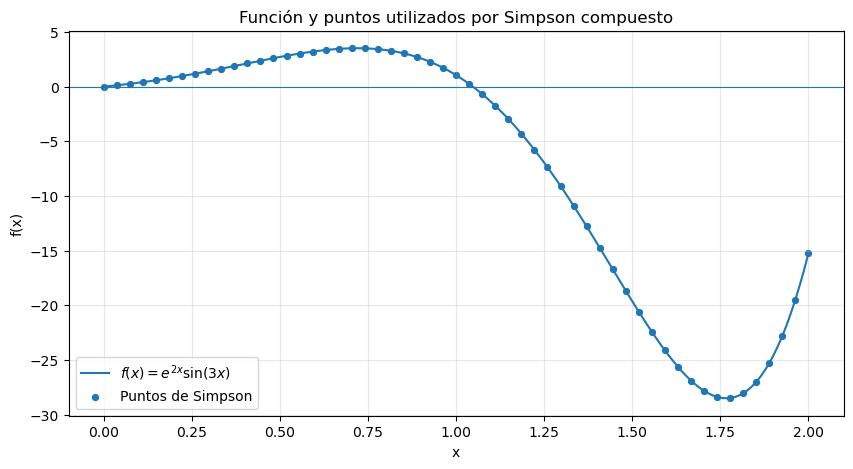

In [26]:
#Puntos para dibujar
x_grafica=np.linspace(a, b, 500)
y_grafica=np.exp(2*x_grafica)*np.sin(3*x_grafica)

#Puntos utilizados por Simpson
x_simpson=np.linspace(a, b, n+1)
y_simpson=np.exp(2*x_simpson)*np.sin(3*x_simpson)

# Crear gráfica
plt.figure(figsize=(10, 5))
plt.plot(x_grafica,y_grafica,label=r"$f(x)=e^{2x}\sin(3x)$")

plt.scatter(x_simpson,y_simpson,s=18,label="Puntos de Simpson")
plt.axhline(0, linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Función y puntos utilizados por Simpson compuesto")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

En este trabajo se implementó la **Regla Compuesta de Simpson** siguiendo la estructura del Algoritmo 4.1 de Burden.
Para la integral $$\int_0^2 e^{2x}\sin(3x)\,dx$$ se determinó, utilizando la cota teórica del error, que era necesario utilizar un número par de subintervalos. Se seleccion $$n=54$$ y por lo tanto $$h=0.0370370370$$

La aproximación obtenida mediante el algoritmo fue $$I\approx -14.2139649001$$

Al compararla con el valor exacto, se obtuvo un error absoluto de aproximadamente $$1.223\times10^{-5}$$
Este error es menor que la tolerancia solicitada, $$1.223\times10^{-5}<10^{-4}$$

Por lo tanto, se concluye que el método proporciona una aproximación que cumple con la precisión requerida.